Step 3.2: Prepare and Understand Data

Loading and Examining the Data
The dataset water_consumption.csv was loaded using the pandas library. Initial exploration via .info() and .describe() confirmed that the dataset contains 600 records and 4 columns (state, sector, date, value). The data types are mostly correct, though the temporal column required transformation for time-series analysis.

Handling Missing Values and Duplicates
A quality check revealed 0 missing values and 0 duplicate records. Because the dataset is completely populated and structurally sound, no imputation strategies (such as mean substitution) or row deletions were necessary. The dataset was left intact to preserve the integrity of the state-by-state consumption records.

Feature Engineering and Transformation
To directly answer the research questions, two specific transformations were applied:

Datetime Conversion & Year Extraction: The date column was converted from a string to a pandas datetime object, and a year column was extracted. This feature engineering is necessary to calculate the time-bound, year-over-year growth metrics required for Q2.

Sector Filtering: A new dataframe (df_industry) was created to isolate records where the sector is nondomestic. This transformation is purposefully connected to Q1 and Q2, ensuring the analysis strictly measures industrial and commercial manufacturing demand rather than residential water usage.

In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('water_consumption.csv')

# 2. Examine structure, data types, and basic descriptive statistics
print("--- Dataset Info ---")
df.info()
print("\n--- Descriptive Statistics ---")
print(df.describe())

# 3. Identify missing values and duplicates
missing_values = df.isnull().sum()
duplicate_records = df.duplicated().sum()
print("\n--- Data Quality Check ---")
print(f"Missing Values:\n{missing_values}\n")
print(f"Duplicate Records: {duplicate_records}")

# 4. Feature Engineering and Data Transformation
# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Extract the 'year' into a new column for easier temporal grouping
df['year'] = df['date'].dt.year

# Create an isolated dataframe for industrial analysis (Q1 & Q2)
df_industry = df[df['sector'] == 'nondomestic'].copy()

print("\n--- Transformed Data Preview (df_industry) ---")
print(df_industry.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   state   600 non-null    object
 1   sector  600 non-null    object
 2   date    600 non-null    object
 3   value   600 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 18.9+ KB

--- Descriptive Statistics ---
             value
count   600.000000
mean    636.530000
std    1224.221968
min       7.000000
25%     150.000000
50%     248.500000
75%     478.750000
max    7540.000000

--- Data Quality Check ---
Missing Values:
state     0
sector    0
date      0
value     0
dtype: int64

Duplicate Records: 0

--- Transformed Data Preview (df_industry) ---
       state       sector       date  value  year
20  Malaysia  nondomestic 2003-01-01   2281  2003
21  Malaysia  nondomestic 2004-01-01   2339  2004
22  Malaysia  nondomestic 2005-01-01   2366  2005
23  Malaysia  nondomestic 2006

Step 3.3: Conduct Analysis

To directly address the research questions, three distinct analytical operations were performed:

Time-Series Aggregation (Answers Q1):

What & Why: We grouped the nondomestic water consumption data by state and year. This establishes the baseline trend of industrial demand across all regions over the 20-year period.

What it reveals: It highlights the macro-level strain that growing industrial sectors place on state water infrastructure, setting the stage for targeted sustainability efforts.

Year-Over-Year (YoY) Growth Calculation (Answers Q2):

What & Why: By isolating the last decade (2012–2022), pivoting the data, and calculating the mean percentage change across years, we identified which states are experiencing the most rapid industrial expansion.

What it reveals: The output shows Perlis, Johor, and Sarawak as the top three. The strong growth in Johor is particularly notable given its heavy manufacturing footprint and active industrial zones like Pasir Gudang. This indicates where future automation and water-recycling investments are most urgently needed.

Proportional Sector Analysis (Prepares Q3):

What & Why: We calculated the ratio of non-domestic to total water consumption for key industrial hubs (Johor, Selangor, Pulau Pinang) compared to the national average for the most recent year (2022).

What it reveals: By comparing these industrial heavyweights against the national baseline, we can measure how intensely the manufacturing sector competes with domestic users for local resources.

In [ ]:
# --- Analytical Operation 1: Time-Series Aggregation (Q1) ---
# Group by state and year to track the trend of non-domestic consumption
state_yearly_trend = df_industry.groupby(['state', 'year'])['value'].sum().reset_index()
print("--- Top 5 Records: Non-Domestic Trend ---")
print(state_yearly_trend.head())

# --- Analytical Operation 2: YoY Growth Calculation 2012-2022 (Q2) ---
# Filter for the last decade of data
df_decade = df_industry[(df_industry['year'] >= 2012) & (df_industry['year'] <= 2022)]

# Pivot the table to have years as columns and states as rows
pivot_recent = df_decade.pivot(index='state', columns='year', values='value')

# Calculate the average Year-over-Year percentage change
yoy_growth = pivot_recent.pct_change(axis='columns').mean(axis=1) * 100
top_3_growth = yoy_growth.nlargest(3)

print("\n--- Top 3 States by Avg YoY Industrial Water Growth (2012-2022) ---")
print(top_3_growth.round(2).astype(str) + '%')

# --- Analytical Operation 3: Proportional Sector Analysis for 2022 (Q3) ---
# Isolate 2022 data
df_2022 = df[df['year'] == 2022].copy()

# Calculate total consumption per state and sector
sector_totals = df_2022.pivot_table(index='state', columns='sector', values='value', aggfunc='sum')
sector_totals['total'] = sector_totals['domestic'] + sector_totals['nondomestic']
sector_totals['nondomestic_pct'] = (sector_totals['nondomestic'] / sector_totals['total']) * 100

# Calculate National Average
national_nondomestic = sector_totals['nondomestic'].sum()
national_total = sector_totals['total'].sum()
national_avg_pct = (national_nondomestic / national_total) * 100

# Isolate key industrial states
key_states = ['Johor', 'Selangor', 'Pulau Pinang']
key_states_data = sector_totals.loc[key_states, ['nondomestic_pct']]

print("\n--- Non-Domestic Consumption Proportion (2022) ---")
print(key_states_data.round(2).astype(str) + '%')
print(f"\nNational Average: {national_avg_pct:.2f}%")

--- Top 5 Records: Non-Domestic Trend ---
   state  year  value
0  Johor  2003    246
1  Johor  2004    225
2  Johor  2005    235
3  Johor  2006    255
4  Johor  2007    289

--- Top 3 States by Avg YoY Industrial Water Growth (2012-2022) ---
state
Perlis     8.81%
Johor      4.92%
Sarawak    3.38%
dtype: object

--- Non-Domestic Consumption Proportion (2022) ---
sector       nondomestic_pct
state                       
Johor                  38.2%
Selangor              37.71%
Pulau Pinang          38.48%

National Average: 37.61%


Step 3.4: Visualise Meaningfully

Visualisation 1: Non-Domestic Water Consumption Trends Across Malaysian States (2003-2022)

Interpretation: This line chart illustrates the 20-year trajectory of industrial water demand across all states. While some regions show stagnant or volatile usage, powerhouses like Selangor and Johor demonstrate massive, sustained upward trends. The significance here is clear: as Malaysia pushes toward automation and expanded manufacturing, the absolute volume of resource consumption in these localized industrial zones is scaling rapidly, underscoring the urgent need for sustainable, closed-loop water systems in factories.

Visualisation 2: Top 3 States by Average Annual Industrial Water Growth (2012-2022)

Interpretation: This bar chart highlights the three states experiencing the most rapid acceleration in non-domestic water demand over the last decade. While Perlis shows the highest percentage growth (likely due to a smaller baseline), Johor's ~4.92% average annual growth is highly significant. Given the dense concentration of manufacturing facilities and industrial estates in the southern region, this compounding growth rate points to rapidly expanding heavy industry that will require targeted environmental compliance monitoring.

Visualisation 3: Proportion of Non-Domestic Water Consumption: Industrial Hubs vs National Average (2022)

Interpretation: This bar chart compares the percentage of non-domestic water use in key manufacturing hubs against the national baseline. In 2022, the national average for industrial/commercial water use sat just above 30%. However, states like Johor and Pulau Pinang significantly exceed this baseline, with non-domestic sectors commanding a much larger share of the local water supply. This visual confirms that sustainability initiatives and automation investments should not be distributed evenly across the country, but rather targeted specifically at these high-density industrial regions where manufacturing competes heavily with domestic resources.

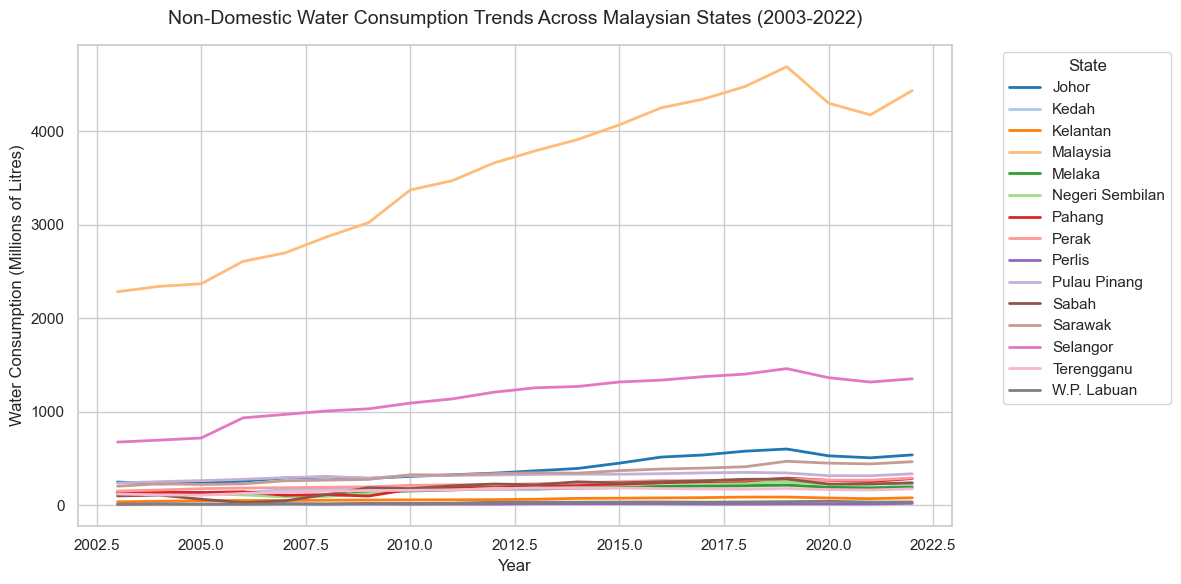

C:\Users\tiong\AppData\Local\Temp\ipykernel_31164\891459799.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_3_growth.index, y=top_3_growth.values, palette='viridis')


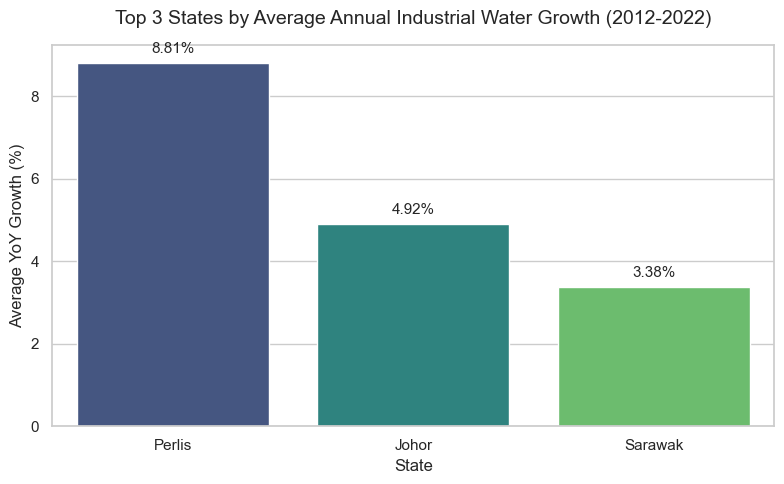

C:\Users\tiong\AppData\Local\Temp\ipykernel_31164\891459799.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x='Region', y='Non-Domestic Proportion (%)', palette=colors)


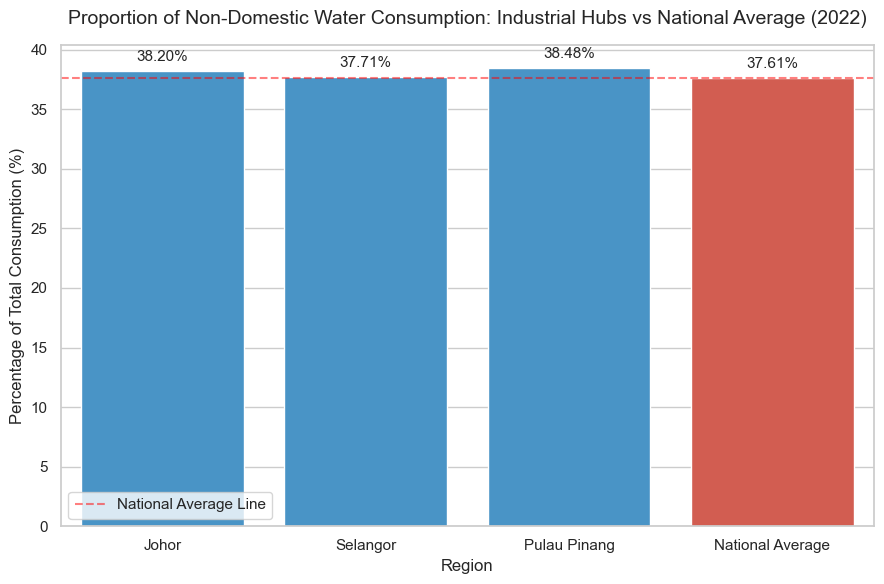

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# --- Visualisation 1: Trend over Time (Answers Q1) ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=state_yearly_trend, x='year', y='value', hue='state', palette='tab20', linewidth=2)
plt.title('Non-Domestic Water Consumption Trends Across Malaysian States (2003-2022)', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Water Consumption (Millions of Litres)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='State')
plt.tight_layout()
plt.savefig('vis1_trend_analysis.png', dpi=300) # Saves the file for your deliverables
plt.show()

# --- Visualisation 2: Top 3 YoY Growth (Answers Q2) ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=top_3_growth.index, y=top_3_growth.values, palette='viridis')
plt.title('Top 3 States by Average Annual Industrial Water Growth (2012-2022)', fontsize=14, pad=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Average YoY Growth (%)', fontsize=12)

# Add data labels to the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, 
                xytext=(0, 5), textcoords='offset points')
    
plt.tight_layout()
plt.savefig('vis2_yoy_growth.png', dpi=300)
plt.show()

# --- Visualisation 3: Proportional Comparison (Answers Q3) ---
# Combine key states and national average for plotting
plot_data = key_states_data.copy()
plot_data.loc['National Average'] = [national_avg_pct]
plot_data = plot_data.reset_index()
plot_data.columns = ['Region', 'Non-Domestic Proportion (%)']

plt.figure(figsize=(9, 6))
# Highlight the national average in a different color
colors = ['#3498db', '#3498db', '#3498db', '#e74c3c'] 
ax = sns.barplot(data=plot_data, x='Region', y='Non-Domestic Proportion (%)', palette=colors)

plt.title('Proportion of Non-Domestic Water Consumption: Industrial Hubs vs National Average (2022)', fontsize=14, pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage of Total Consumption (%)', fontsize=12)

# Add a dashed line across the chart to emphasize the national average
plt.axhline(national_avg_pct, color='red', linestyle='--', alpha=0.5, label='National Average Line')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, 
                xytext=(0, 5), textcoords='offset points')

plt.legend()
plt.tight_layout()
plt.savefig('vis3_proportion_comparison.png', dpi=300)
plt.show()